In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_circles.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [5]:
bundles['LVM-30Dor-6563_C0']

{'bundle_name': 'LVM-30Dor-6563_C0',
 'data': 'LVM-30Dor-6563_C0',
 'obs':           RAdeg      DEdeg     V_mean        log_F   sigma        v_  \
 0     84.725370 -69.212071   2.869628   43123.0731  0.7404  272.1742   
 1     84.750499 -69.206908   1.507711   30051.8798  0.7754  270.8693   
 2     84.775616 -69.201741   3.948021   39320.8326  0.7941  273.3667   
 3     84.800721 -69.196571   0.942857   23293.0888  0.8114  270.4187   
 4     84.825814 -69.191397  -5.113582   17936.2851  0.7531  264.4195   
 ...         ...        ...        ...          ...     ...       ...   
 5412  84.872407 -69.091172 -19.738646  200949.5122  0.8716  250.5243   
 5413  84.898588 -69.095523  -4.606139  139740.6508  0.8126  265.6500   
 5414  84.924779 -69.099870 -10.798550  101658.2753  1.0483  259.4508   
 5415  84.950893 -69.104216   2.164516   80881.4144  0.7976  272.4070   
 5416  84.977105 -69.108555   4.533665   59347.3160  0.8121  274.7694   
 
            v_mod  
 0     269.304572  
 1     2

In [6]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [7]:
dfs_obs["LVM-30Dor-6563_C0"].describe()

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
count,5417.000000,5417.000000,5417.000000,5.417000e+03,5417.000000,5417.000000,5417.000000
mean,84.681381,-69.098087,-5.235732,1.443377e+05,0.862525,264.811290,270.047022
std,0.160689,0.055899,9.903468,1.560704e+05,0.106625,9.827619,0.414297
min,84.354396,-69.214183,-46.670257,9.809583e+03,0.338400,223.539100,269.198082
25%,84.550394,-69.141996,-11.082144,5.783269e+04,0.789100,259.129500,269.710984
50%,84.687426,-69.096715,-5.099728,9.942341e+04,0.834300,264.938800,270.059657
75%,84.808593,-69.054911,0.049052,1.673457e+05,0.906700,269.833200,270.369944
max,84.995301,-68.985478,47.760732,1.710726e+06,1.499300,317.811500,270.860308


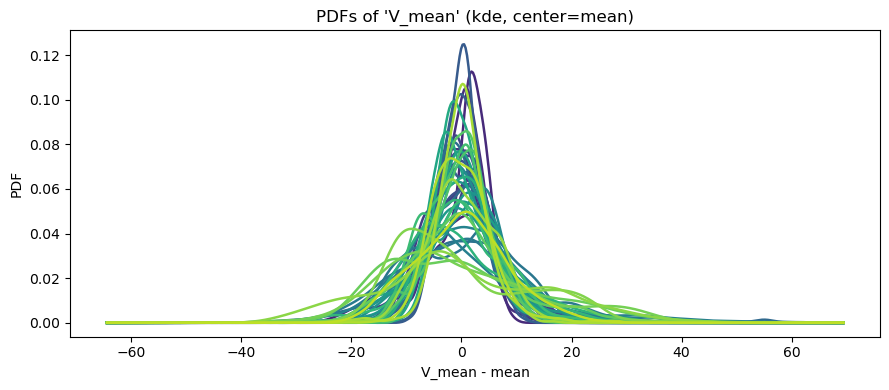

In [8]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [9]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-6563_C0,5417,-5.235732,9.903468,98.078669,-41.434525,52.996463
1,LVM-30Dor-6563_I1,5001,-2.606887,4.769923,22.752168,-18.700827,10.356281
2,LVM-30Dor-6563_I2,4825,-2.293748,4.268749,18.222220,-16.782701,19.611694
3,LVM-30Dor-6563_I3,5075,-3.356050,5.729341,32.825346,-32.947317,20.673996
4,LVM-30Dor-6563_I4,4550,0.705195,6.628019,43.930632,-18.435278,27.647620
5,LVM-30Dor-6563_I5,4314,-3.401179,7.628253,58.190245,-35.286170,34.136913
6,LVM-30Dor-6563_I6,4790,-3.090972,4.695526,22.047965,-15.316105,18.473668
7,LVM-30Dor-6563_I7,4607,-1.579738,5.344002,28.558362,-20.639149,18.863192
8,LVM-30Dor-6563_I8,4435,-0.804394,6.441874,41.497740,-23.117609,22.768809
9,LVM-30Dor-6563_M1,3532,1.801404,5.452838,29.733442,-16.552706,16.206642


In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle


c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [11]:
name_file = "LVM-30Dor-6563"   # adjust if needed

circles_df = pd.read_csv("fits_ready/circle_catalog.csv")
circles_df["name"] = [f"{name_file}_{lab}" for lab in circles_df["label"]]

In [12]:

circles = []
for _, row in circles_df.iterrows():
    center = SkyCoord(
        ra=row["ra_deg"] * u.deg,
        dec=row["dec_deg"] * u.deg,
        frame="icrs"
    )

    circles.append({
        "name": row["name"],
        "label": row["label"],
        "ring": row["ring"],
        "angle_deg": row["angle_deg"],
        "center": center,
        "ra_deg": row["ra_deg"],
        "dec_deg": row["dec_deg"],
        "radius_arcsec": row["radius_arcsec"],
    })

In [13]:
#circles

In [14]:
#circles

Text(0.5, 1.0, 'Circle regions')

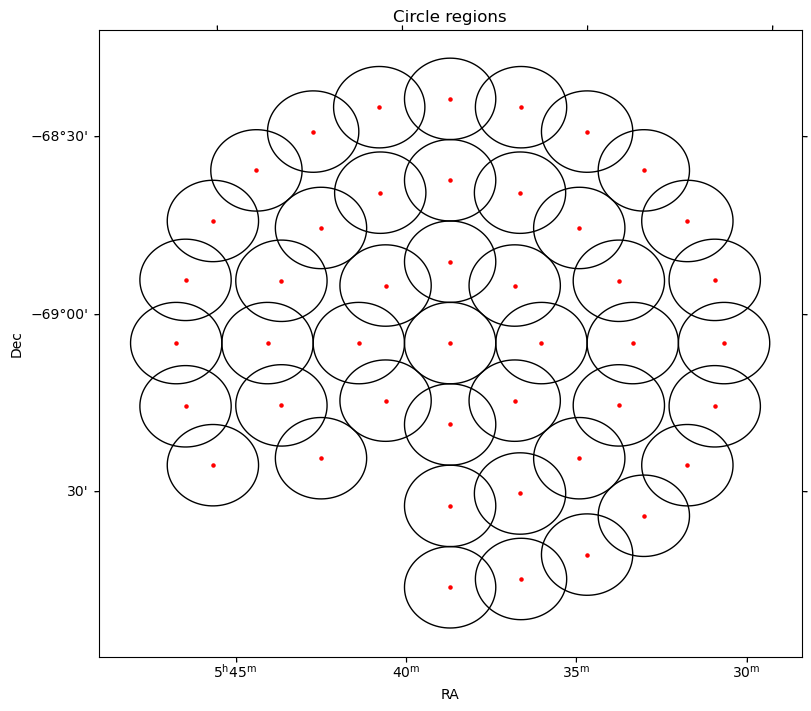

In [15]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(8, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

for item in circles:
    # draw center point
    ax.scatter(
        item["ra_deg"],
        item["dec_deg"],
        s=5,
        color="red",
        transform=ax.get_transform("world")
    )

    # draw circle
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1.0,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'Circle regions')

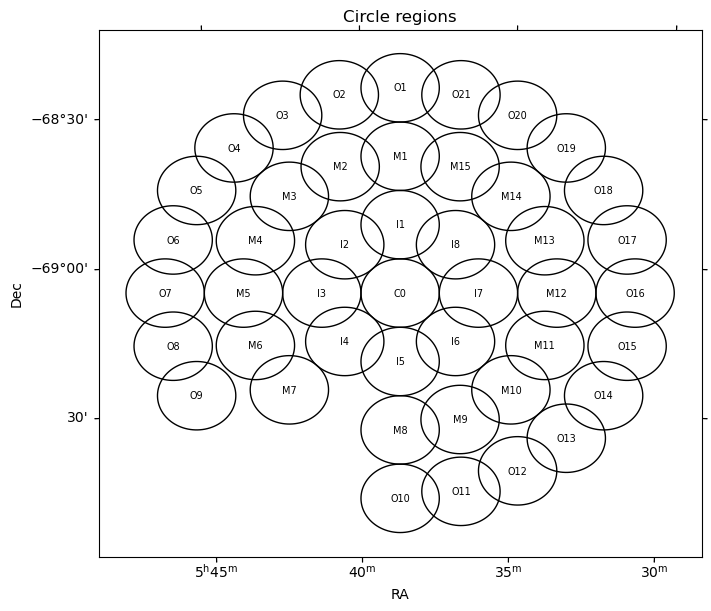

In [16]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'sig2 by circle')

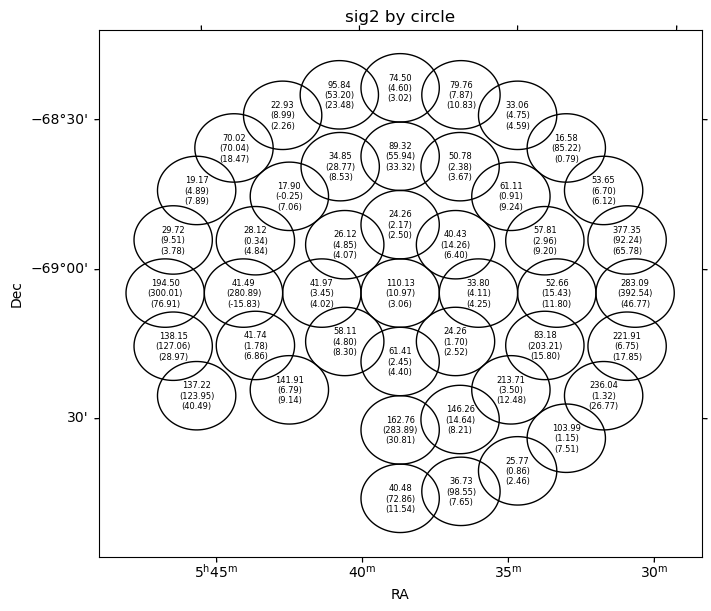

In [17]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=6,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

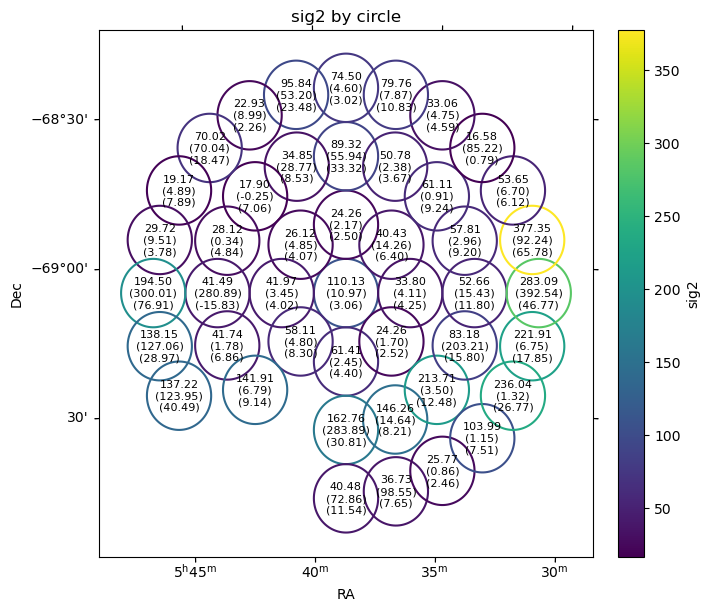

In [18]:
import matplotlib as mpl

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

# values used for the colormap: first row of sig2 in each circle
sig2_main = [dfs_fit[item["name"]]["sig2"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(sig2_main), vmax=max(sig2_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,   # bigger text
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("sig2")

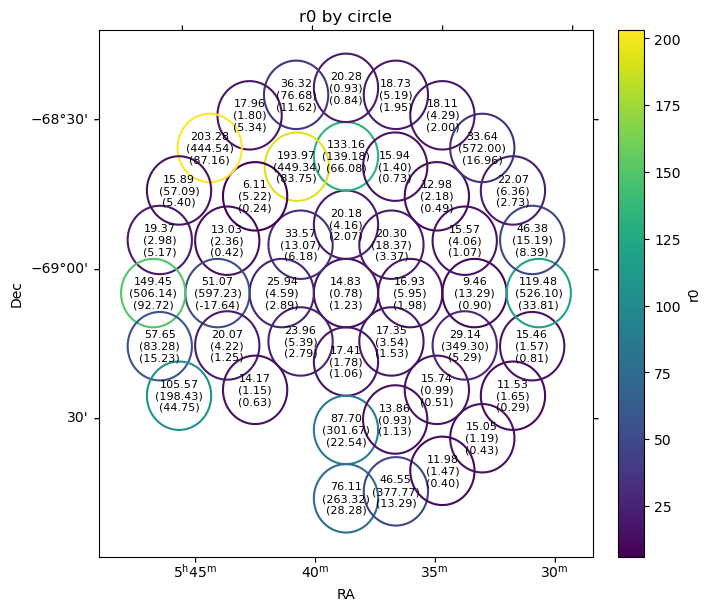

In [19]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

r0_main = [dfs_fit[item["name"]]["r0"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(r0_main), vmax=max(r0_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["r0"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("r0 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("r0")

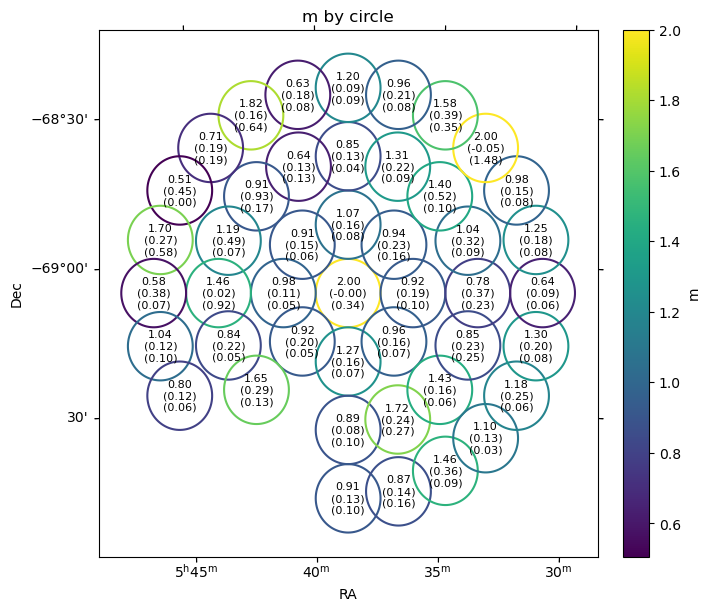

In [20]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

m_main = [dfs_fit[item["name"]]["m"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(m_main), vmax=max(m_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["m"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("m by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("m")

In [21]:
bundles['LVM-30Dor-6563_C0']

{'bundle_name': 'LVM-30Dor-6563_C0',
 'data': 'LVM-30Dor-6563_C0',
 'obs':           RAdeg      DEdeg     V_mean        log_F   sigma        v_  \
 0     84.725370 -69.212071   2.869628   43123.0731  0.7404  272.1742   
 1     84.750499 -69.206908   1.507711   30051.8798  0.7754  270.8693   
 2     84.775616 -69.201741   3.948021   39320.8326  0.7941  273.3667   
 3     84.800721 -69.196571   0.942857   23293.0888  0.8114  270.4187   
 4     84.825814 -69.191397  -5.113582   17936.2851  0.7531  264.4195   
 ...         ...        ...        ...          ...     ...       ...   
 5412  84.872407 -69.091172 -19.738646  200949.5122  0.8716  250.5243   
 5413  84.898588 -69.095523  -4.606139  139740.6508  0.8126  265.6500   
 5414  84.924779 -69.099870 -10.798550  101658.2753  1.0483  259.4508   
 5415  84.950893 -69.104216   2.164516   80881.4144  0.7976  272.4070   
 5416  84.977105 -69.108555   4.533665   59347.3160  0.8121  274.7694   
 
            v_mod  
 0     269.304572  
 1     2

In [22]:
circles[0]

{'name': 'LVM-30Dor-6563_C0',
 'label': 'C0',
 'ring': 'center',
 'angle_deg': nan,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (84.675, -69.1)>,
 'ra_deg': 84.675,
 'dec_deg': -69.1,
 'radius_arcsec': 413.0}

Group params and ring

In [23]:
import numpy as np
import pandas as pd

rows = []

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    sig2_main = df_fit["sig2"].iloc[0]
    sig_main = np.sqrt(sig2_main)

    rows.append({
        "name": name,
        "label": item["label"],
        "ring": item["ring"],
        "angle_deg": item["angle_deg"],
        "sig2": sig2_main,
        "sig": sig_main,
        "r0": df_fit["r0"].iloc[0],
        "m": df_fit["m"].iloc[0],
    })

results_df = pd.DataFrame(rows)
results_df

,name,label,ring,angle_deg,sig2,sig,r0,m
0,LVM-30Dor-6563_C0,C0,center,NaN,110.133960,10.494473,14.829088,2.000000
1,LVM-30Dor-6563_I1,I1,inner,0.0,24.256030,4.925041,20.182064,1.066867
2,LVM-30Dor-6563_I2,I2,inner,45.0,26.119774,5.110751,33.573168,0.909124
3,LVM-30Dor-6563_I3,I3,inner,90.0,41.967432,6.478228,25.936047,0.982047
4,LVM-30Dor-6563_I4,I4,inner,135.0,58.105428,7.622692,23.961107,0.923208
5,LVM-30Dor-6563_I5,I5,inner,180.0,61.411781,7.836567,17.414547,1.270119
6,LVM-30Dor-6563_I6,I6,inner,225.0,24.255909,4.925029,17.349156,0.956110
7,LVM-30Dor-6563_I7,I7,inner,270.0,33.798680,5.813663,16.926624,0.920518
8,LVM-30Dor-6563_I8,I8,inner,315.0,40.427975,6.358300,20.301293,0.941080
9,LVM-30Dor-6563_M1,M1,middle,0.0,89.315034,9.450663,133.159865,0.851497


Sigma

In [24]:
ring_stats = (
    results_df
    .groupby("ring")["sig"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,10.494473,NaN,10.494473
1,inner,8,6.133784,1.156138,6.085981
2,middle,15,8.539710,3.043530,7.603122
3,outer,21,9.481236,4.487104,8.631369


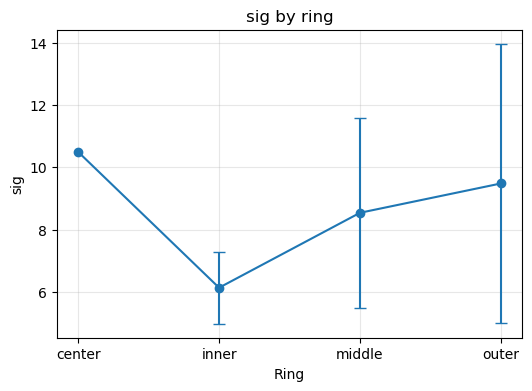

In [25]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("sig")
ax.set_title("sig by ring")
ax.grid(True, alpha=0.3)

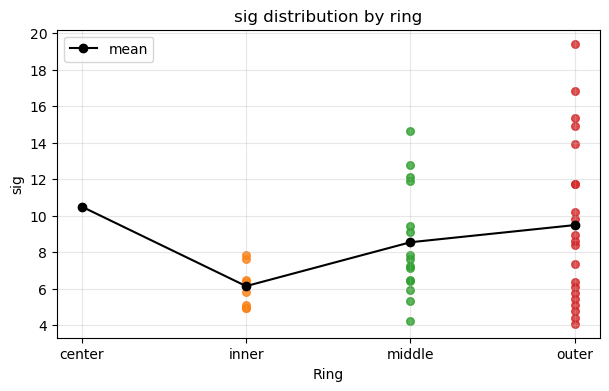

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "sig"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("sig")
ax.set_title("sig distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()

r0

In [27]:
ring_stats = (
    results_df
    .groupby("ring")["r0"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,14.829088,NaN,14.829088
1,inner,8,21.955501,5.705225,20.241679
2,middle,15,42.130722,54.696535,15.735513
3,outer,21,50.517029,52.269573,22.067685


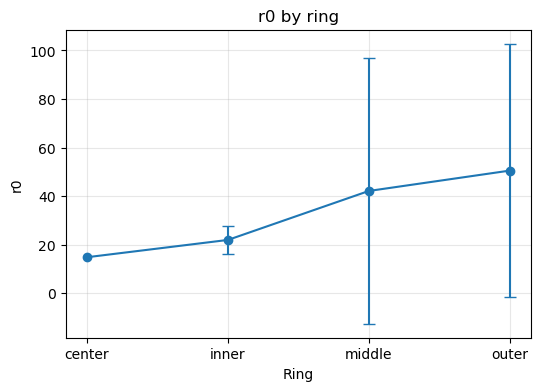

In [28]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("r0")
ax.set_title("r0 by ring")
ax.grid(True, alpha=0.3)

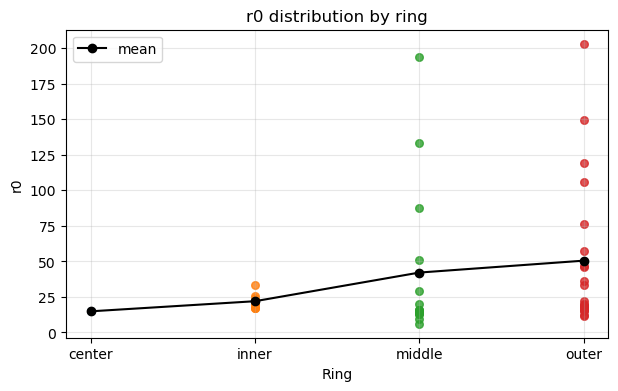

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "r0"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("r0")
ax.set_title("r0 distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()

m

In [30]:
ring_stats = (
    results_df
    .groupby("ring")["m"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,2.000000,NaN,2.000000
1,inner,8,0.996134,0.121602,0.948595
2,middle,15,1.132155,0.342558,1.038371
3,outer,21,1.105009,0.421825,1.036128


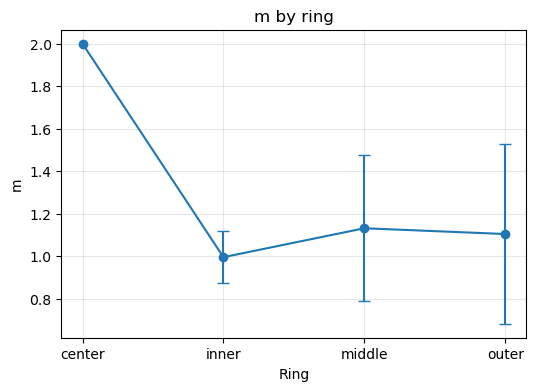

In [31]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("m")
ax.set_title("m by ring")
ax.grid(True, alpha=0.3)

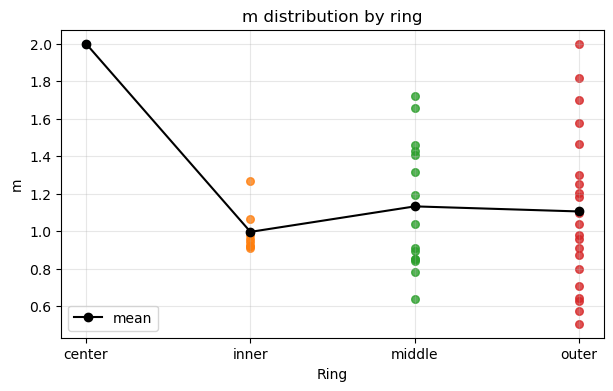

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "m"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("m")
ax.set_title("m distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()